In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)

In [37]:
import pandas as pd
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets = ['OAT', 'AIMHIGH', 'PEACE', 'SPRINT', 'ACCORD', 'BARI2D']
outcomes = ['comb', 'Primary', 'PRIMARY', 'PRIMARY','','']
locations = ['datasets/OAT/Ancillary/', 'datasets/AIMHIGH/', 'datasets/PEACE/Data/', 'datasets/SPRINT_POP/Datasets/', 
            'datasets/ACCORD/', 'datasets/']
intervention = ['Percutaneous coronary intervention', 'Niacin', 'Trandolapril', 'SBP target <120mm Hg', {'Intensive Glycemia', 'Intensive BP', 'Lipid Fibrate'}]

ACCORD

In [85]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', outcome='', intervention='BP')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:741: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

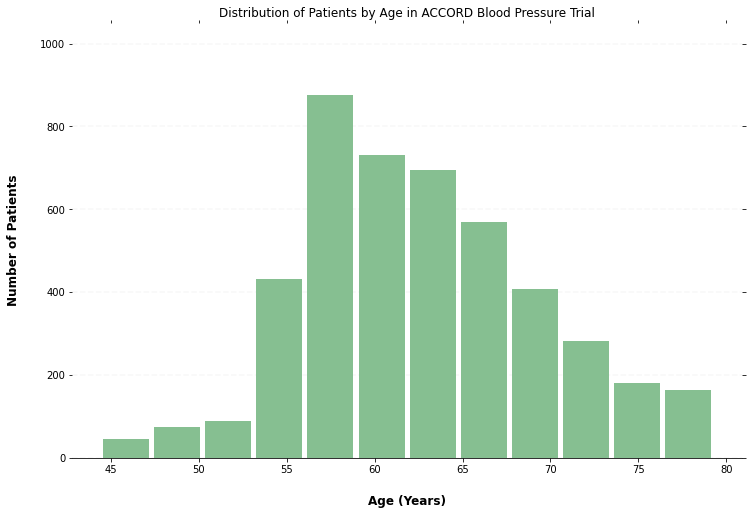

In [11]:
age_hist = features.hist(column='Baseline_Age', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

age_hist = age_hist[0]
for x in age_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Age in ACCORD Blood Pressure Trial")

    # Set x-axis label
    x.set_xlabel("Age (Years)", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

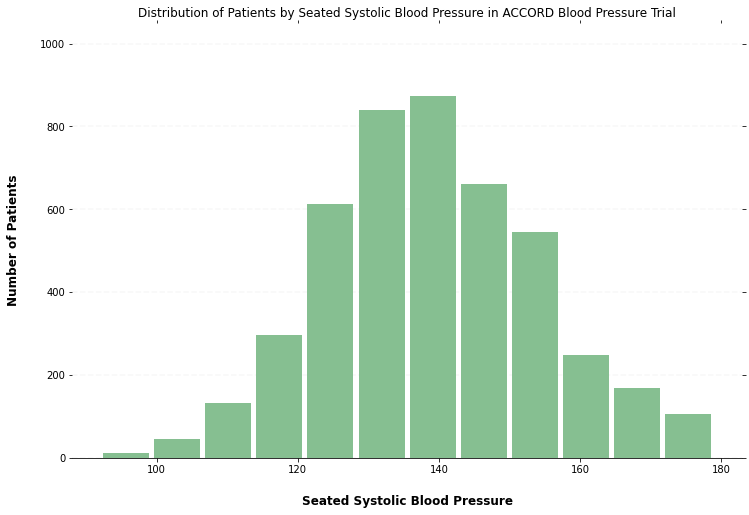

In [12]:
SBP_hist = features.hist(column='Baseline_Seated_Systolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

SBP_hist = SBP_hist[0]
for x in SBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Systolic Blood Pressure in ACCORD Blood Pressure Trial")

    # Set x-axis label
    x.set_xlabel("Seated Systolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

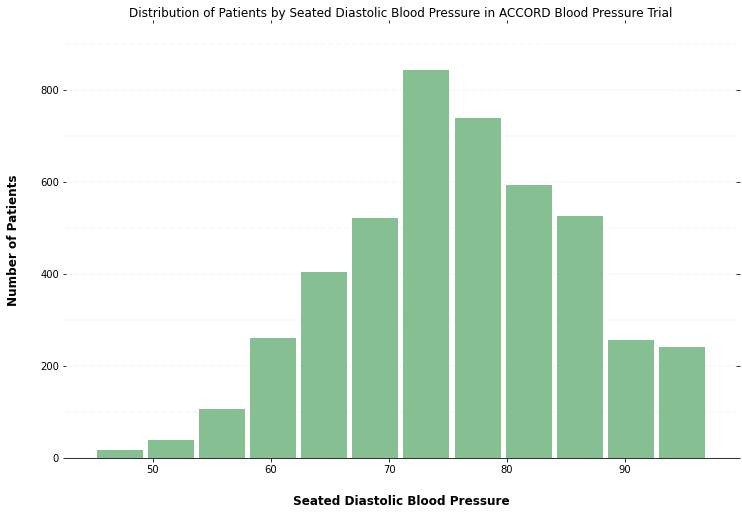

In [13]:
DBP_hist = features.hist(column='Baseline_Seated_Diastolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

DBP_hist = DBP_hist[0]
for x in DBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Diastolic Blood Pressure in ACCORD Blood Pressure Trial")

    # Set x-axis label
    x.set_xlabel("Seated Diastolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

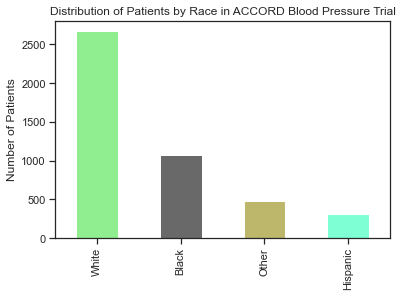

In [86]:
features['Race'].value_counts().plot(kind="bar", title="Distribution of Patients by Race in ACCORD Blood Pressure Trial", color=['lightgreen', 'dimgray', 'darkkhaki', 'aquamarine'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

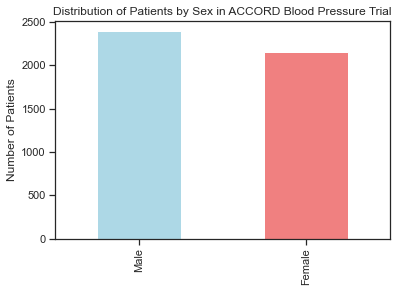

In [87]:
features['Sex'].value_counts().plot(kind="bar", title="Distribution of Patients by Sex in ACCORD Blood Pressure Trial", color=['lightblue', 'lightcoral'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

In [36]:
cat_feats=['Sex', 'Race']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [38]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [39]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [42]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='Intensive Blood Pressure', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\models\cmhe\cmhe_utilities.py:121: RuntimeWarning: invalid value encountered in log
  probs.append(np.log(event_probs))
100%|██████████| 100/100 [00:19<00:00,  5.06it/s]


In [43]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
zeta

array([1, 1, 1, ..., 0, 1, 0], dtype=int64)

In [44]:
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

In [46]:
from auton_survival import reporting
import matplotlib.pyplot as plt

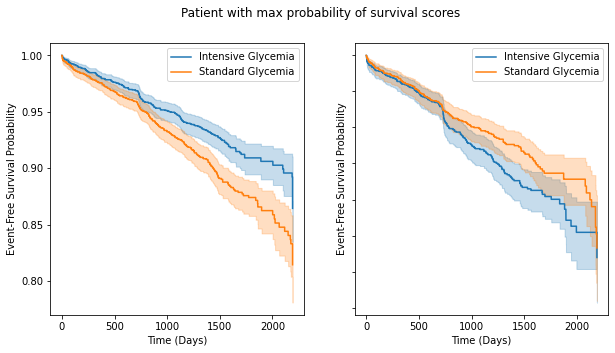

In [146]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Glycemia', 'Standard Glycemia'], loc="upper right")
plt.show()

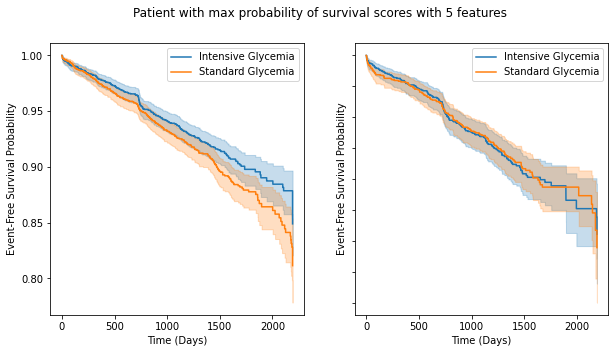

In [157]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores with 5 features')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Glycemia', 'Standard Glycemia'], loc="upper right")
plt.show()

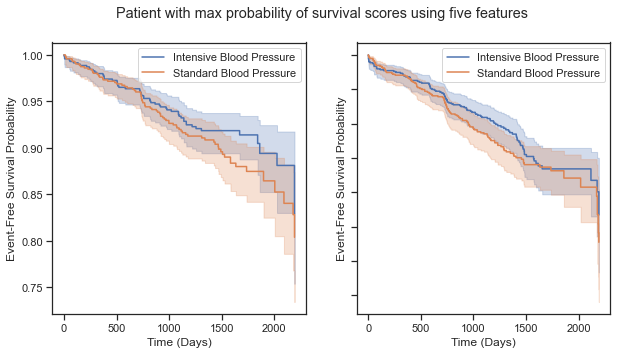

In [47]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores using five features')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Blood Pressure', 'Standard Blood Pressure'], loc="upper right")
plt.show()

ACCORD GLYCEMIA

In [72]:
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', outcome='', intervention='Glycemia')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:741: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

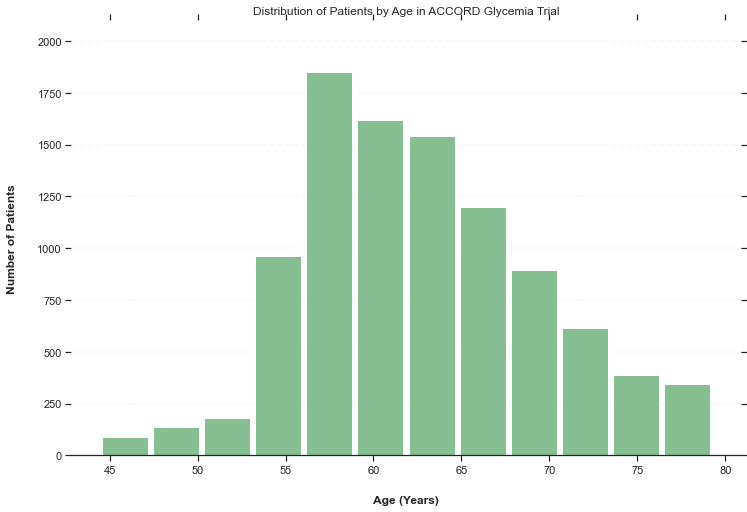

In [73]:
age_hist = features.hist(column='Baseline_Age', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

age_hist = age_hist[0]
for x in age_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Age in ACCORD Glycemia Trial")

    # Set x-axis label
    x.set_xlabel("Age (Years)", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

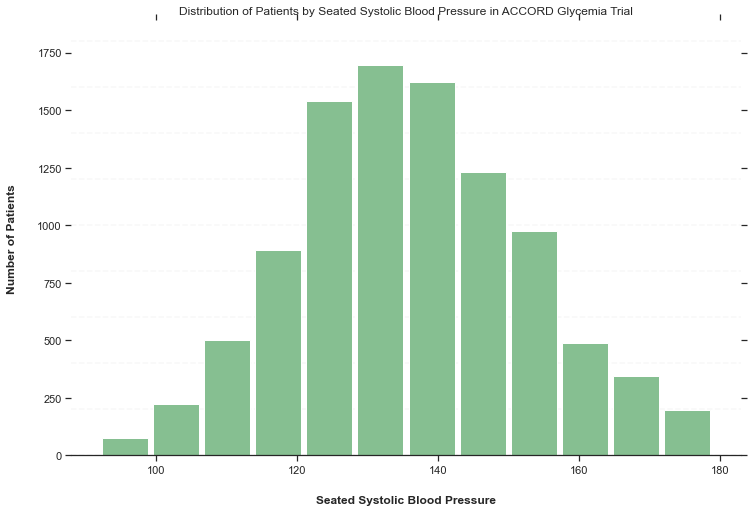

In [74]:
SBP_hist = features.hist(column='Baseline_Seated_Systolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

SBP_hist = SBP_hist[0]
for x in SBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Systolic Blood Pressure in ACCORD Glycemia Trial")

    # Set x-axis label
    x.set_xlabel("Seated Systolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

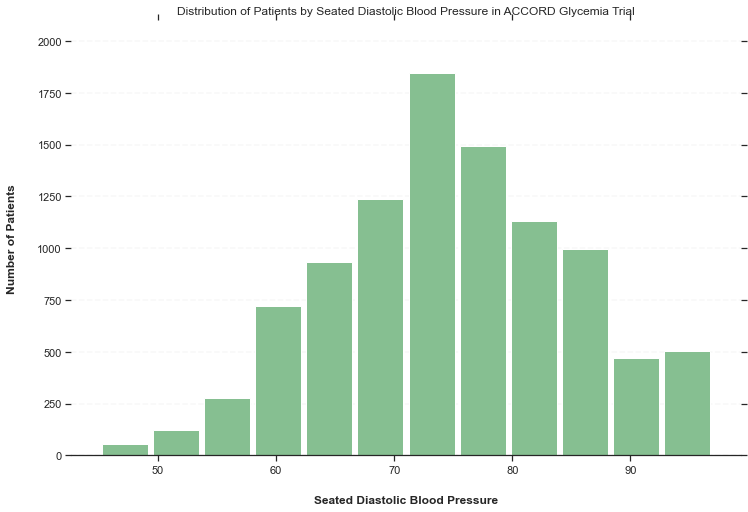

In [75]:
DBP_hist = features.hist(column='Baseline_Seated_Diastolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

DBP_hist = DBP_hist[0]
for x in DBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Diastolic Blood Pressure in ACCORD Glycemia Trial")

    # Set x-axis label
    x.set_xlabel("Seated Diastolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

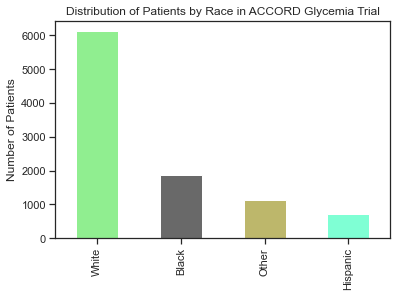

In [76]:
features['Race'].value_counts().plot(kind="bar", title="Distribution of Patients by Race in ACCORD Glycemia Trial", color=['lightgreen', 'dimgray', 'darkkhaki', 'aquamarine'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

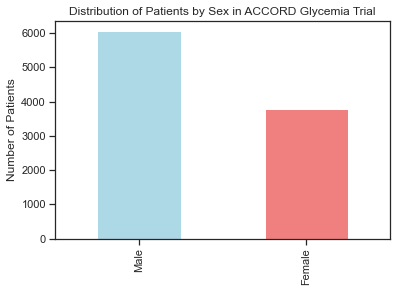

In [77]:
features['Sex'].value_counts().plot(kind="bar", title="Distribution of Patients by Sex in ACCORD Glycemia Trial", color=['lightblue', 'lightcoral'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

In [78]:
cat_feats=['Sex', 'Race']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [80]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='Intensive Glycemia', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:49<00:00,  2.00it/s]


In [81]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

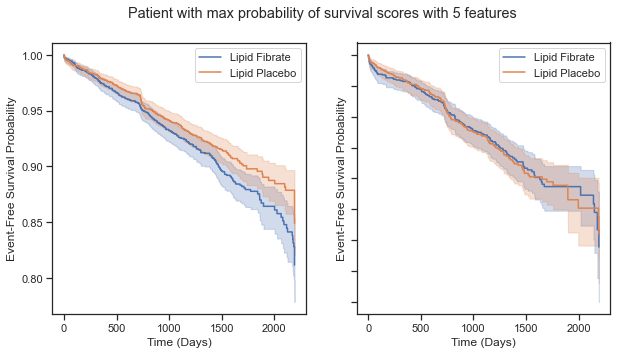

In [82]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores with 5 features')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

LIPID

In [83]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', outcome='', intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:741: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

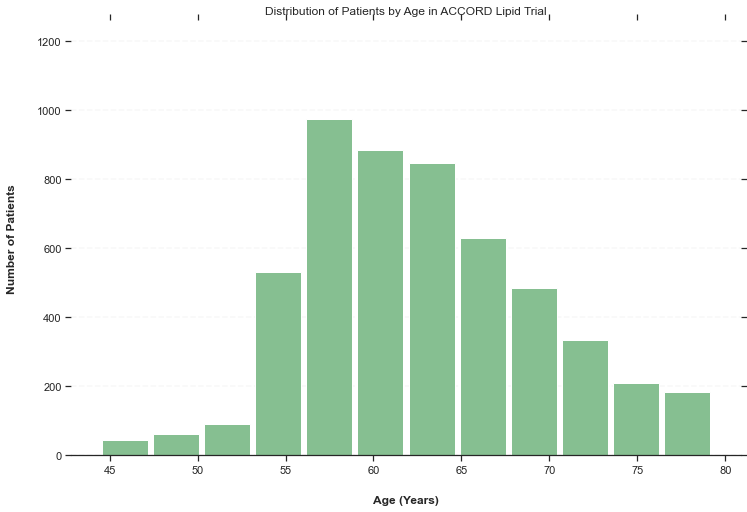

In [55]:
age_hist = features.hist(column='Baseline_Age', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

age_hist = age_hist[0]
for x in age_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Age in ACCORD Lipid Trial")

    # Set x-axis label
    x.set_xlabel("Age (Years)", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

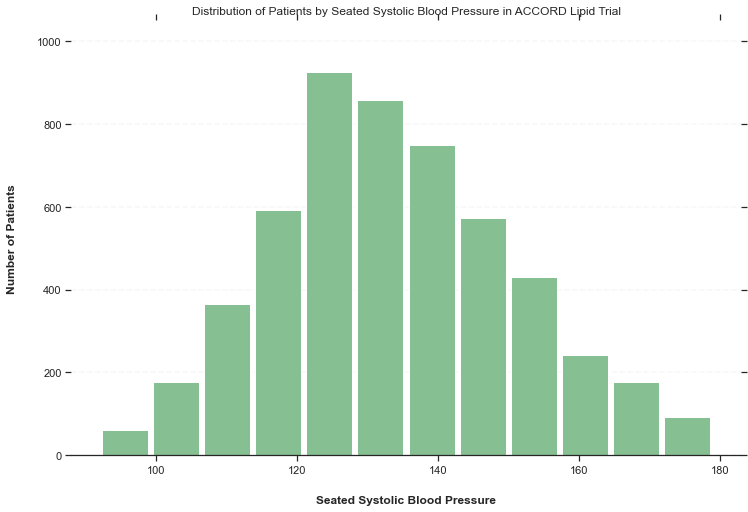

In [56]:
SBP_hist = features.hist(column='Baseline_Seated_Systolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

SBP_hist = SBP_hist[0]
for x in SBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Systolic Blood Pressure in ACCORD Lipid Trial")

    # Set x-axis label
    x.set_xlabel("Seated Systolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

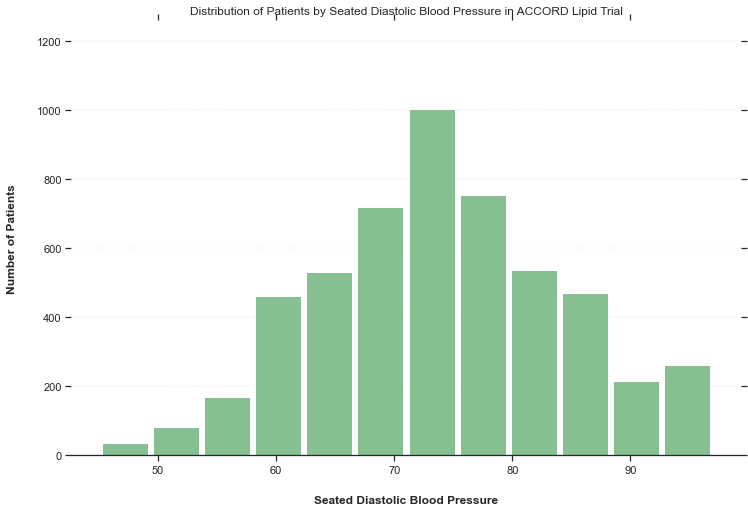

In [57]:
DBP_hist = features.hist(column='Baseline_Seated_Diastolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

DBP_hist = DBP_hist[0]
for x in DBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Diastolic Blood Pressure in ACCORD Lipid Trial")

    # Set x-axis label
    x.set_xlabel("Seated Diastolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

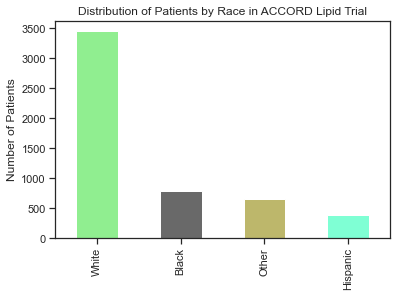

In [61]:
features['Race'].value_counts().plot(kind="bar", title="Distribution of Patients by Race in ACCORD Lipid Trial", color=['lightgreen', 'dimgray', 'darkkhaki', 'aquamarine'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

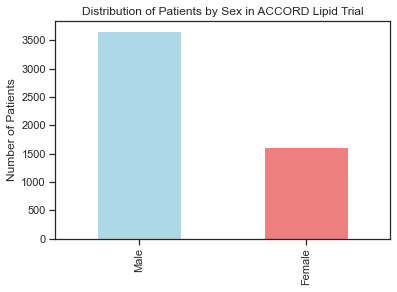

In [84]:
features['Sex'].value_counts().plot(kind="bar", title="Distribution of Patients by Sex in ACCORD Lipid Trial", color=['lightblue', 'lightcoral'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

In [62]:
cat_feats=['Sex', 'Race']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [63]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [65]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='Lipid Fibrate', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:20<00:00,  4.97it/s]


In [66]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

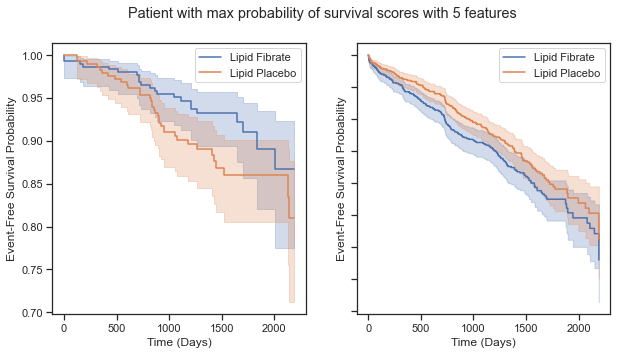

In [67]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores with 5 features')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

PEACE

In [125]:
from datasets_retrospective import load_peace_dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_dataset(location='datasets/PEACE/Data/', outcome='PRIMARY')

(8290, 7)
(8290, 39)
(8290, 7)
(8290, 39)


In [116]:
# cat_feats=['Sex']
# num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [126]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [127]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [128]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='Trandolapril', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

 31%|███       | 31/100 [00:10<00:22,  3.01it/s]


In [129]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
zeta

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [130]:
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

In [134]:
idx_list_0

(array([   0,    1,    2, ..., 8287, 8288, 8289], dtype=int64),)

In [135]:
idx_list_1

(array([2523, 3641, 7090], dtype=int64),)

In [123]:
from auton_survival import reporting
import matplotlib.pyplot as plt

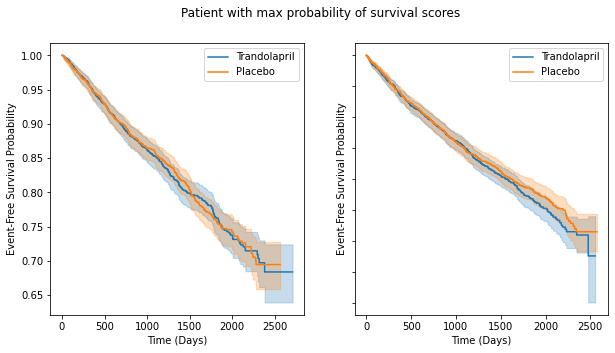

In [124]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

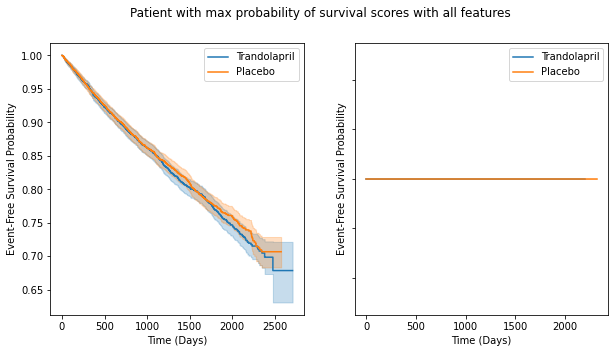

In [131]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores with all features')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

SPRINT

In [15]:
from datasets_retrospective import load_sprint_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_dataset(location='datasets/SPRINT_POP/Datasets/', outcome='PRIMARY')

(9361, 27)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWar

In [18]:
features.head()

,Baseline_BMI,Baseline_History_Chronic_Kidney_Disease,Baseline_10-year_Casdiovascular_disease_risk>15%,Baseline_Estimation_10-year_Casdiovascular_disease_risk,Baseline_Urine_albumin,Baseline_Serum_creatinine,Baseline_History_Subclinical_Cardiovascular_Disease,Baseline_HDL_Cholesterol,Baseline_History_Aspirin,Baseline_Seated_Systolic_Blood_Pressure,...,Baseline_Age,Baseline_Systolic_Blood_Pressure_Tertile,Baseline_On_Statin,Baseline_Number_medications_prescribed,Baseline_Estimated_Glomerular_Filtration_Rate,Baseline_History_Clinical_Cardiovascular_Disease,Baseline_>75_years_old,Baseline_Triglycerides,Sex,Baseline_Seated_Diastolic_Blood_Pressure
S00007,33.115201,No,Yes,29.732061,5.80,1.11,No,36.0,Yes,145.0,...,60.0,3.0,Yes,2.0,67.69,Yes,No,92.0,Male,80.0
S00010,28.842380,No,Yes,29.677619,5.45,1.17,No,61.0,Yes,138.0,...,75.0,2.0,Yes,1.0,60.64,No,Yes,188.0,Male,71.0
S00022,24.888358,No,No,9.597287,NaN,0.71,No,53.0,No,144.0,...,56.0,2.0,Yes,3.0,85.09,No,No,183.0,Female,84.0
S00038,33.643060,No,Yes,17.443819,13.33,1.09,No,47.0,No,143.0,...,62.0,2.0,No,2.0,68.44,No,No,125.0,Male,92.0
S00045,29.337871,No,No,8.627849,6.12,0.78,No,89.0,No,123.0,...,75.0,1.0,No,2.0,71.94,No,Yes,109.0,Female,68.0


In [83]:
cat_feats=['Sex', 'Race']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [29]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=['Sex', 'Race'], num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure'])

In [30]:
features.head()

,Baseline_Age,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Seated_Diastolic_Blood_Pressure,Sex_Male,Race_HISPANIC,Race_OTHER,Race_WHITE
S00007,-0.840770,0.342168,0.156733,1,0,0,1
S00010,0.752309,-0.107192,-0.596824,1,0,0,1
S00022,-1.265591,0.277974,0.491647,0,1,0,0
S00038,-0.628359,0.213780,1.161475,1,0,0,1
S00045,0.752309,-1.070106,-0.848010,0,0,0,1


In [31]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [32]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='SBP target <120mm Hg'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 6552
Number of test data points: 2809


In [55]:
x_tr = x_train.values.astype('float32')
t_tr = y_train['time'].values.astype('float32')
e_tr = y_train['event'].values.astype('float32')
a_tr = intervention[y_train.index]=='SBP target <120mm Hg'

In [58]:
x_te = x_test.values.astype('float32')
t_te = y_test['time'].values.astype('float32')
e_te = y_test['event'].values.astype('float32')
a_te = intervention[y_test.index]=='SBP target <120mm Hg'

In [59]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

 73%|███████▎  | 73/100 [00:17<00:06,  4.14it/s]


In [60]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

In [61]:
idx_list_0 = np.where(zeta_train == 0)
idx_list_1 = np.where(zeta_train == 1)

In [45]:
from auton_survival import reporting
import matplotlib.pyplot as plt

In [64]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([0, 1, 1, ..., 1, 1, 1], dtype=int64)

In [65]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

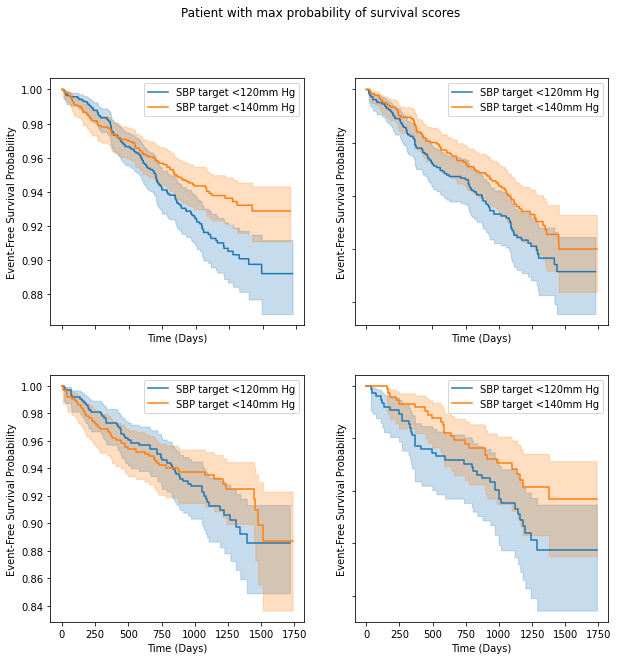

In [70]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_0], a_tr.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_1], a_tr.iloc[idx_list_1], ax=ax2)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], a_te.iloc[idx_list_0te], ax=ax3) 
reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], a_te.iloc[idx_list_1te], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data

In [71]:
q = [0.9, 0.8, 0.7, 0.6]
# Zeta 0
zeta_train_qt = np.quantile(zeta_probs_train[:, 0], q)

In [72]:
idx_list_qt10 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[0])
idx_list_qt20 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[1])
idx_list_qt30 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[2])
idx_list_qt40 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[3])

In [73]:
# Zeta 0
zeta_test_qt = np.quantile(zeta_probs_test[:, 0], q)

In [74]:
idx_list_qt10te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[0])
idx_list_qt20te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[1])
idx_list_qt30te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[2])
idx_list_qt40te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[3])

In [75]:
# Zeta 1
zeta_train_qt1 = np.quantile(zeta_probs_train[:, 1], q)

In [76]:
idx_list_qt10_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[0])
idx_list_qt20_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[1])
idx_list_qt30_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[2])
idx_list_qt40_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[3])

In [77]:
# zeta 1
zeta_test_qt1 = np.quantile(zeta_probs_test[:, 1], q)
idx_list_qt10te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[0])
idx_list_qt20te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[1])
idx_list_qt30te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[2])
idx_list_qt40te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[3])

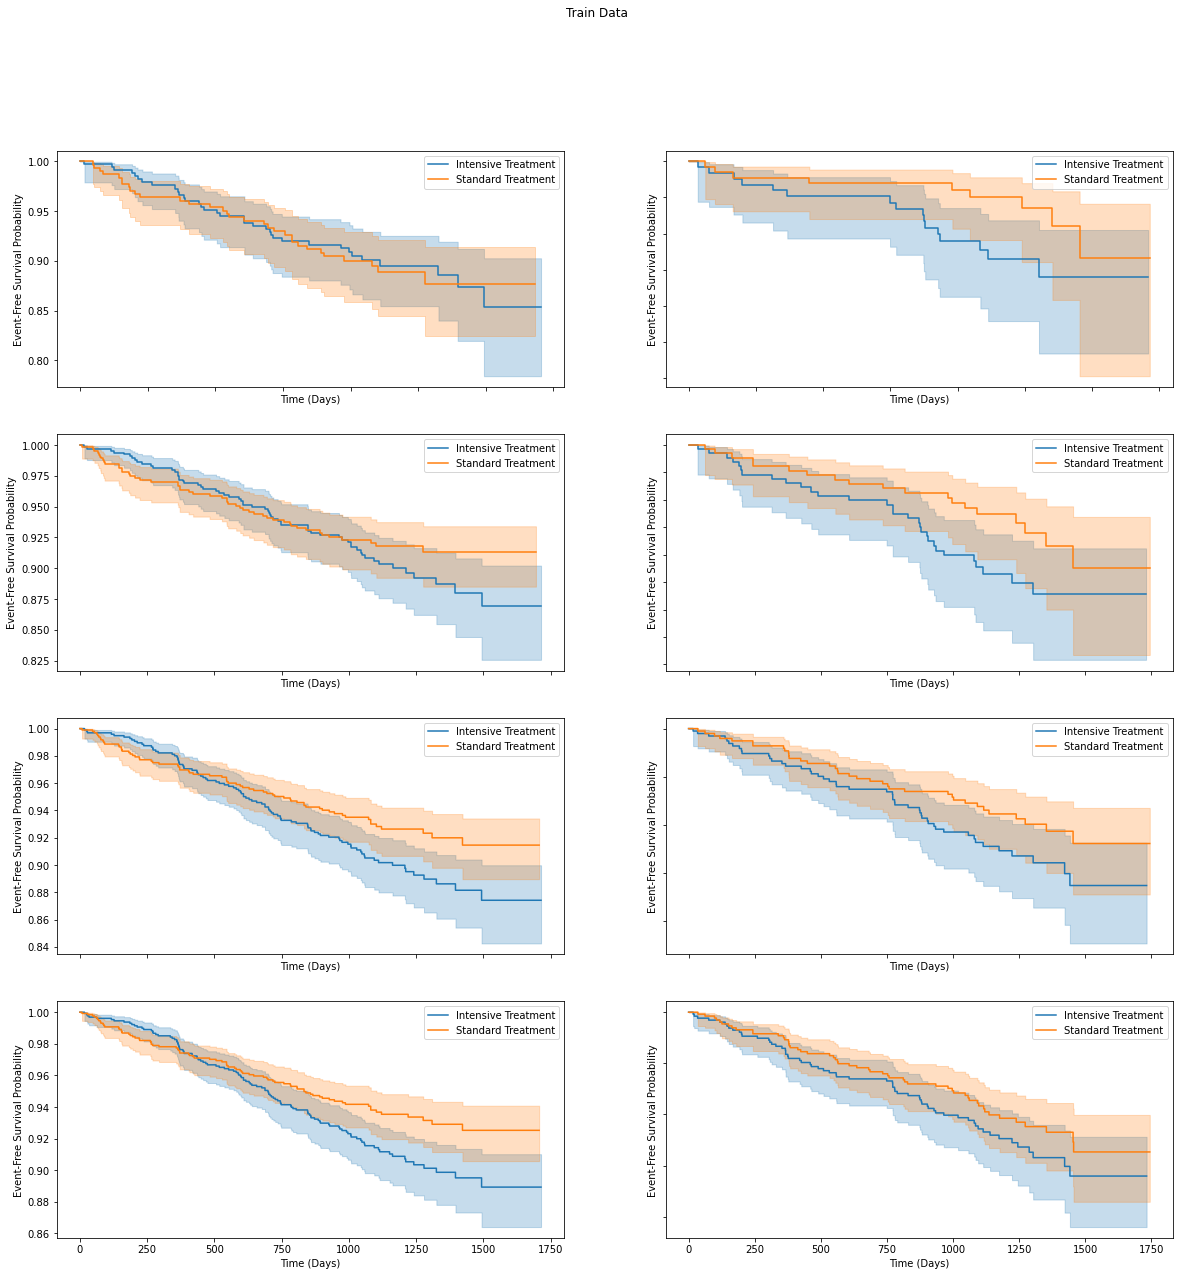

In [78]:
fig, ((ax5, ax13), (ax6, ax14), (ax7, ax15), (ax8, ax16)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Train Data')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10], a_tr.iloc[idx_list_qt10], ax=ax5)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20], a_tr.iloc[idx_list_qt20], ax=ax6)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30], a_tr.iloc[idx_list_qt30], ax=ax7) 
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40], a_tr.iloc[idx_list_qt40], ax=ax8)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10_1], a_tr.iloc[idx_list_qt10_1], ax=ax13)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20_1], a_tr.iloc[idx_list_qt20_1], ax=ax14)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30_1], a_tr.iloc[idx_list_qt30_1], ax=ax15)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40_1], a_tr.iloc[idx_list_qt40_1], ax=ax16) 
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

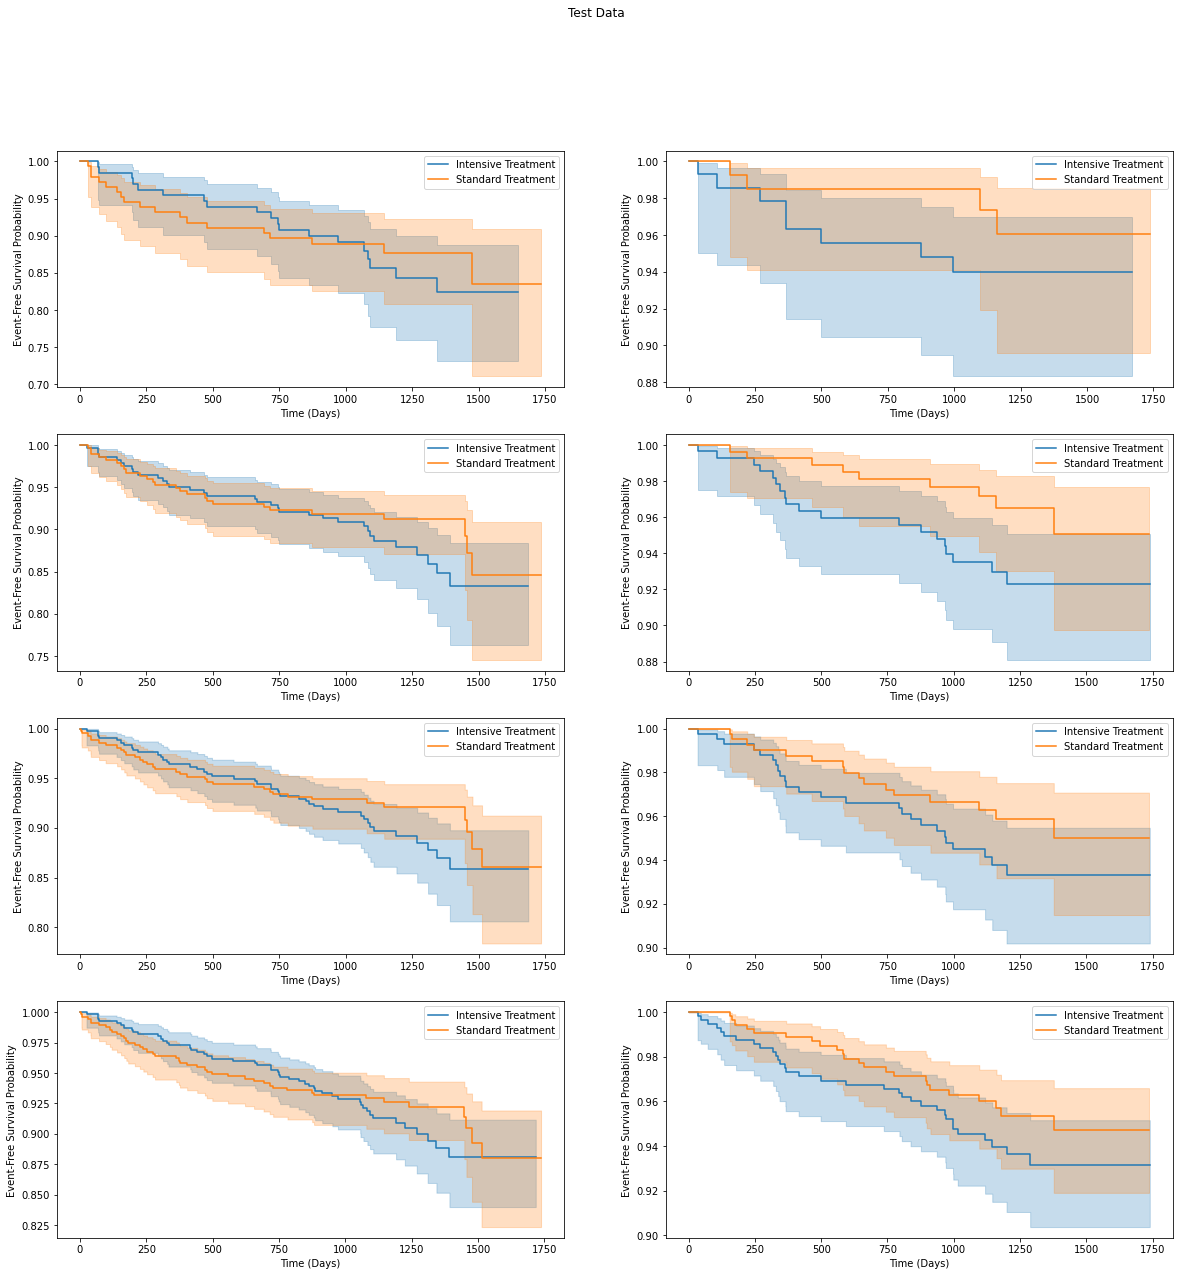

In [79]:
fig, ((ax9, ax17), (ax10, ax18), (ax11, ax19), (ax12, ax20)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Test Data')
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te], a_te.iloc[idx_list_qt10te], ax=ax9)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te], a_te.iloc[idx_list_qt20te], ax=ax10)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te], a_te.iloc[idx_list_qt30te], ax=ax11)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te], a_te.iloc[idx_list_qt40te], ax=ax12)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te_1], a_te.iloc[idx_list_qt10te_1], ax=ax17)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te_1], a_te.iloc[idx_list_qt20te_1], ax=ax18)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te_1], a_te.iloc[idx_list_qt30te_1], ax=ax19)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te_1], a_te.iloc[idx_list_qt40te_1], ax=ax20)
for ax in fig.get_axes():
    # ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()